<a href="https://colab.research.google.com/github/Razzalin/analise-churn-telecom/blob/main/telecomx_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Telecom X - Análise de Evasão de Clientes

## 🎯 Objetivo
Analisar os dados de clientes da Telecom X para identificar fatores que influenciam o churn (cancelamento).

A análise servirá como base para futuras estratégias de retenção e modelos preditivos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:
df.shape

(7267, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [ ]:
df.iloc[0]

,0
customerID,0002-ORFBO
Churn,No
customer,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
phone,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
internet,"{'InternetService': 'DSL', 'OnlineSecurity': '..."
account,"{'Contract': 'One year', 'PaperlessBilling': '..."


In [ ]:
df_final = pd.json_normalize(df.to_dict(orient="records"))

df_final.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
df_final.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [ ]:
df = df_final

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"],
    errors="coerce"
)

In [ ]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [ ]:
df = df.dropna()

In [ ]:
df = df.copy()

In [ ]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [ ]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0.0,0.734215
1.0,0.265785


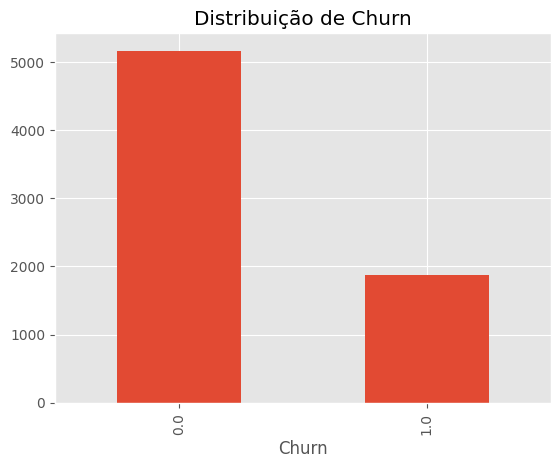

In [ ]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribuição de Churn")
plt.show()

In [ ]:
pd.crosstab(df["account.Contract"], df["Churn"], normalize="index")

Churn,0.0,1.0
account.Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


## 📌 Insight 1: Tipo de Contrato

Clientes com contrato mensal apresentam taxa de churn significativamente maior (42,7%) quando comparados a contratos anuais (11,2%) e de dois anos (2,8%).

Isso indica que contratos de longo prazo aumentam a retenção e reduzem o cancelamento.


In [ ]:
df.groupby("Churn")["customer.tenure"].mean()

,customer.tenure
Churn,
0.0,37.650010
1.0,17.979133


In [ ]:
df_final.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [ ]:
df_final.columns = df_final.columns.str.replace('account.', '', regex=False)
df_final.columns = df_final.columns.str.replace('customer.', '', regex=False)
df_final.columns = df_final.columns.str.replace('phone.', '', regex=False)
df_final.columns = df_final.columns.str.replace('internet.', '', regex=False)

df_final.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

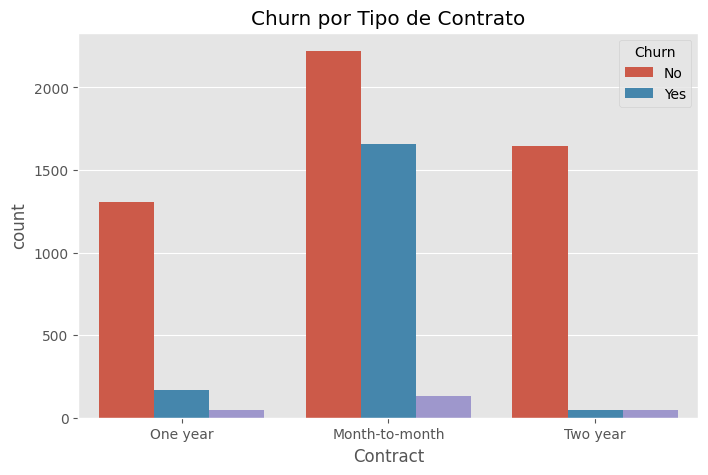

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df_final)
plt.title("Churn por Tipo de Contrato")
plt.show()

In [ ]:
pd.crosstab(df_final['InternetService'],
            df_final['Churn'],
            normalize='index')

Churn,,No,Yes
InternetService,,,
DSL,0.026929,0.788585,0.184486
Fiber optic,0.031895,0.562539,0.405566
No,0.034788,0.893738,0.071474


In [ ]:
pd.crosstab(df_final['SeniorCitizen'],
            df_final['Churn'],
            normalize='index')

Churn,,No,Yes
SeniorCitizen,,,
0,0.030238,0.740838,0.228924
1,0.033841,0.563452,0.402707


In [ ]:
pd.crosstab(df_final['PaymentMethod'],
            df_final['Churn'],
            normalize='index')

Churn,,No,Yes
PaymentMethod,,,
Bank transfer (automatic),0.028320,0.809314,0.162366
Credit card (automatic),0.029337,0.822704,0.147959
Electronic check,0.032720,0.529243,0.438037
Mailed check,0.031832,0.783183,0.184985


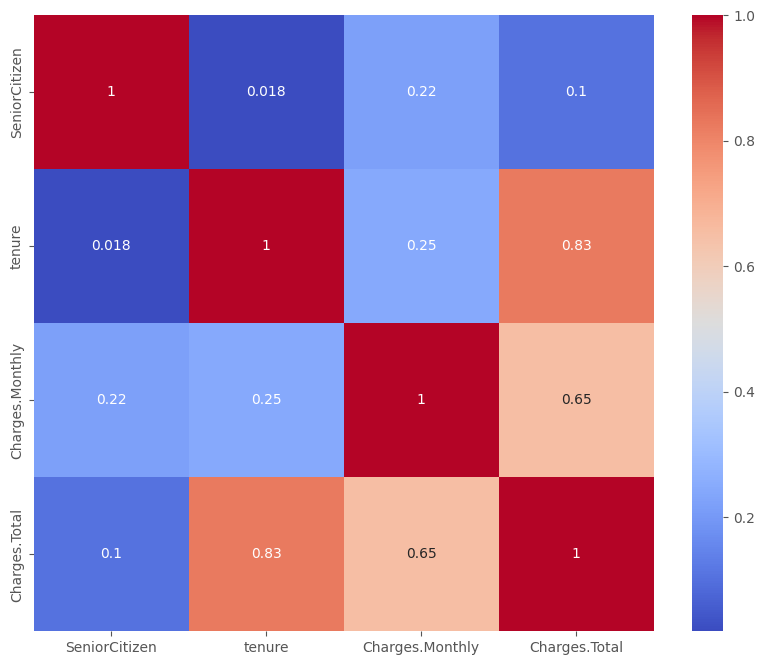

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_final.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

# 📌 Conclusão Final

A análise mostrou que:

- Contratos mensais apresentam maior taxa de churn.
- Clientes com contrato longo são mais fidelizados.
- Método de pagamento eletrônico apresenta maior cancelamento.
- Clientes com menor tempo de contrato tendem a cancelar mais.

## 💡 Insights de Negócio

- Incentivar contratos de longo prazo.
- Criar campanhas de retenção para clientes mensais.
- Melhorar experiência de onboarding nos primeiros meses.

# 📊 Análise de Churn – Telecom

O objetivo deste projeto é analisar os fatores que influenciam o cancelamento (churn) de clientes em uma empresa de telecomunicações.

Através de análise exploratória de dados (EDA), buscamos identificar padrões comportamentais, contratuais e financeiros que impactam a retenção de clientes.

## 🔎 Tratamento dos Dados

- Expansão das colunas estruturadas em formato JSON
- Remoção de colunas aninhadas
- Transformação da variável Churn em formato numérico
- Verificação de valores ausentes

A base de dados não apresentou valores nulos, garantindo integridade para análise.

## 📈 Proporção Geral de Cancelamento

A taxa geral de churn observada foi de aproximadamente 26,5%.

Isso indica que cerca de 1 em cada 4 clientes cancelaram o serviço.

## 📄 Tipo de Contrato e Churn

- Contratos mensais apresentam taxa de churn de 42,7%.
- Contratos anuais apresentam taxa de 11,2%.
- Contratos de dois anos apresentam taxa de apenas 2,8%.

Clientes com contratos de longo prazo demonstram maior fidelização.

Programas de incentivo à migração para contratos de maior duração podem reduzir significativamente a evasão.

## ⏳ Tempo de Permanência

Observou-se correlação negativa entre tempo de contrato e churn.

Clientes com maior tempo de relacionamento possuem menor probabilidade de cancelamento.

Os primeiros meses de relacionamento são críticos para retenção.

## 💰 Valor da Mensalidade

Clientes com mensalidades mais altas apresentam maior probabilidade de churn.

Pode indicar sensibilidade ao preço ou percepção de custo-benefício.

## 🔬 Análise de Correlação

Foi utilizada a matriz de correlação para identificar relações lineares entre variáveis numéricas.

Principais observações:

- Tenure apresentou correlação negativa moderada com churn.
- MonthlyCharges apresentou correlação positiva fraca com churn.
- Clientes com menor tempo de contrato tendem a cancelar mais.

A correlação mede o grau de relação linear entre duas variáveis, variando de -1 a +1.

Valores próximos de -1 indicam relação inversa forte.
Valores próximos de +1 indicam relação direta forte.
Valores próximos de 0 indicam ausência de relação linear.

# 📌 Conclusão Final

A análise permitiu identificar os principais fatores associados ao churn:

- Contratos mensais apresentam maior risco de cancelamento.
- Clientes nos primeiros meses de relacionamento são mais propensos a sair.
- Mensalidades mais elevadas estão associadas a maior evasão.
- Contratos de longo prazo apresentam alta retenção.

## 🎯 Recomendações

- Incentivar contratos de longo prazo.
- Criar programas de retenção nos primeiros meses.
- Monitorar clientes com mensalidade elevada.
- Desenvolver ações preventivas para clientes de alto risco.